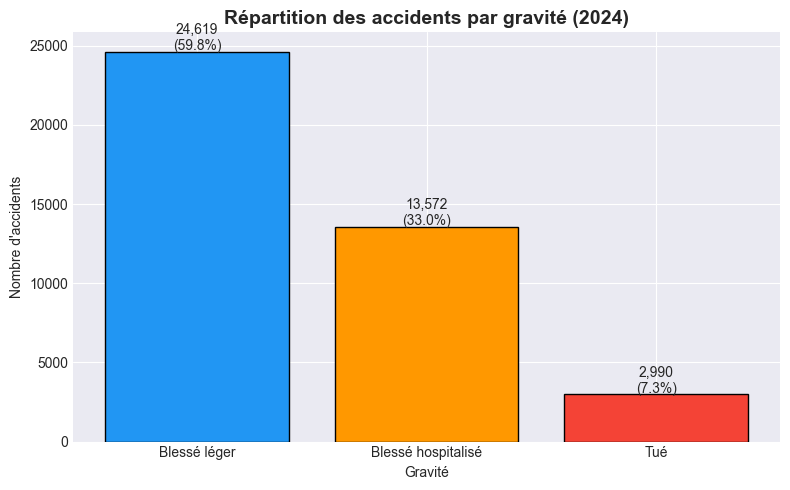

Graphique 1 sauvegardé


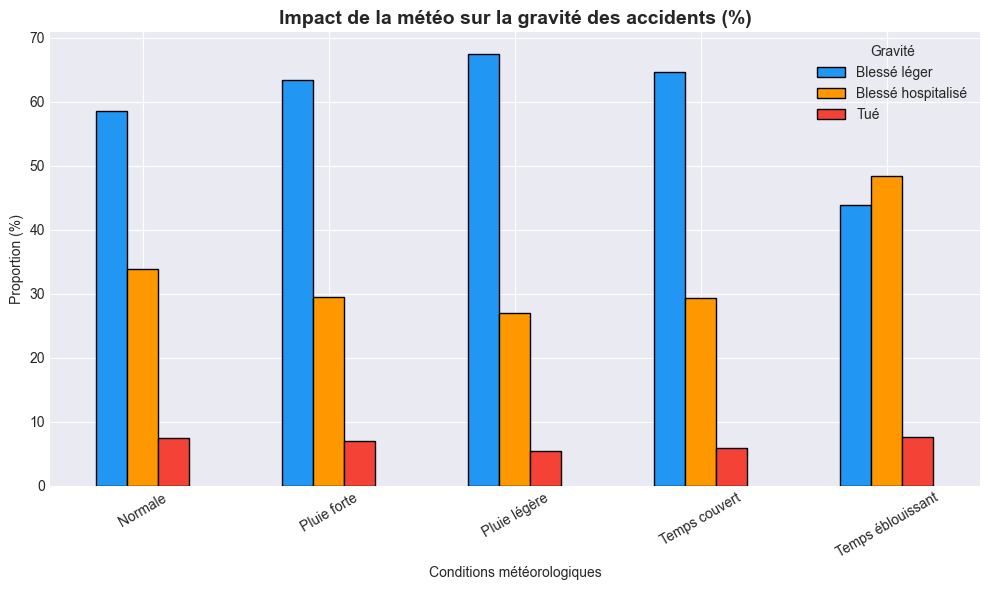

Graphique 2 sauvegardé


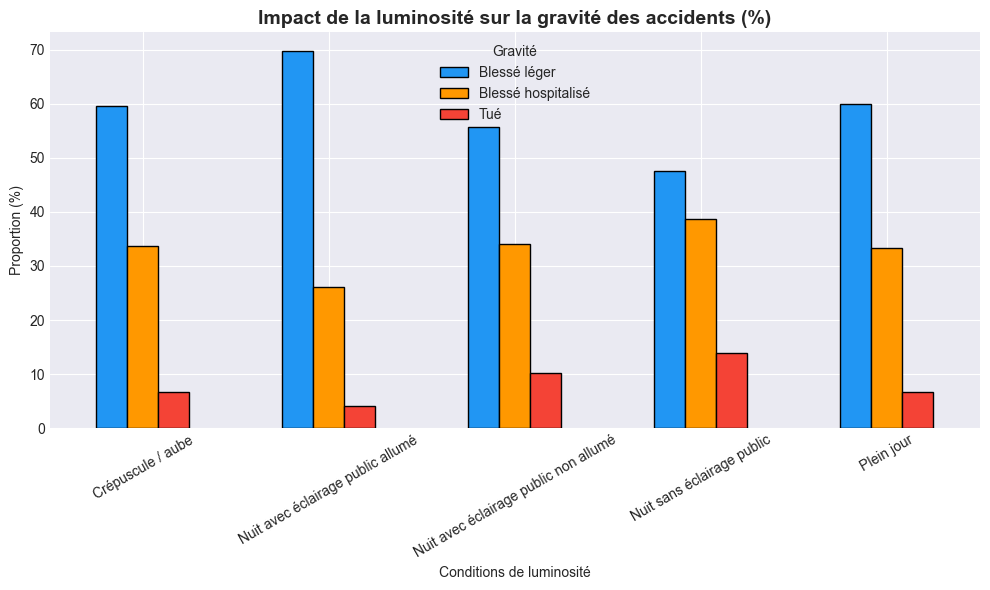

Graphique 3 sauvegardé


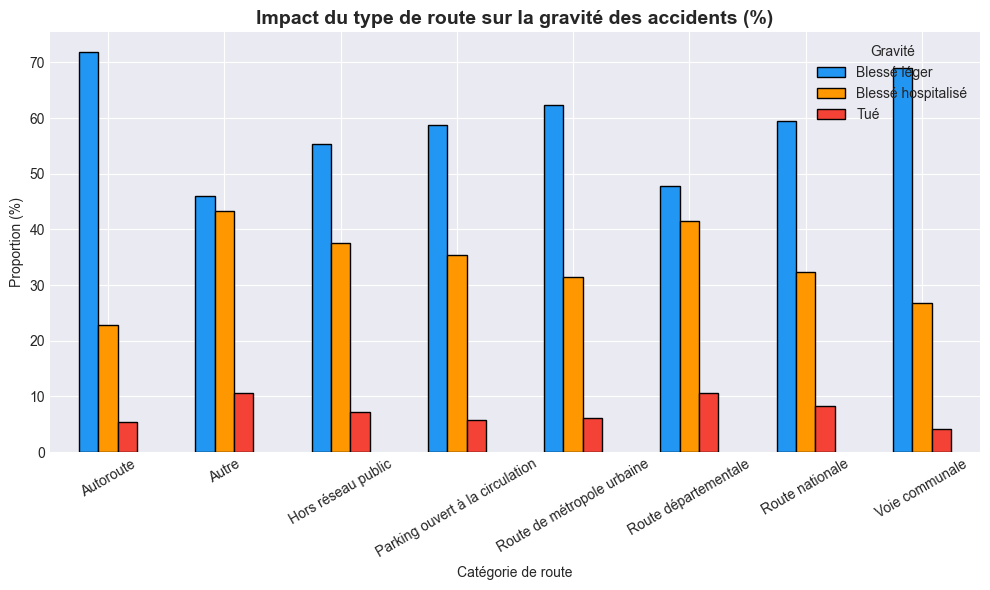

Graphique 4 sauvegardé


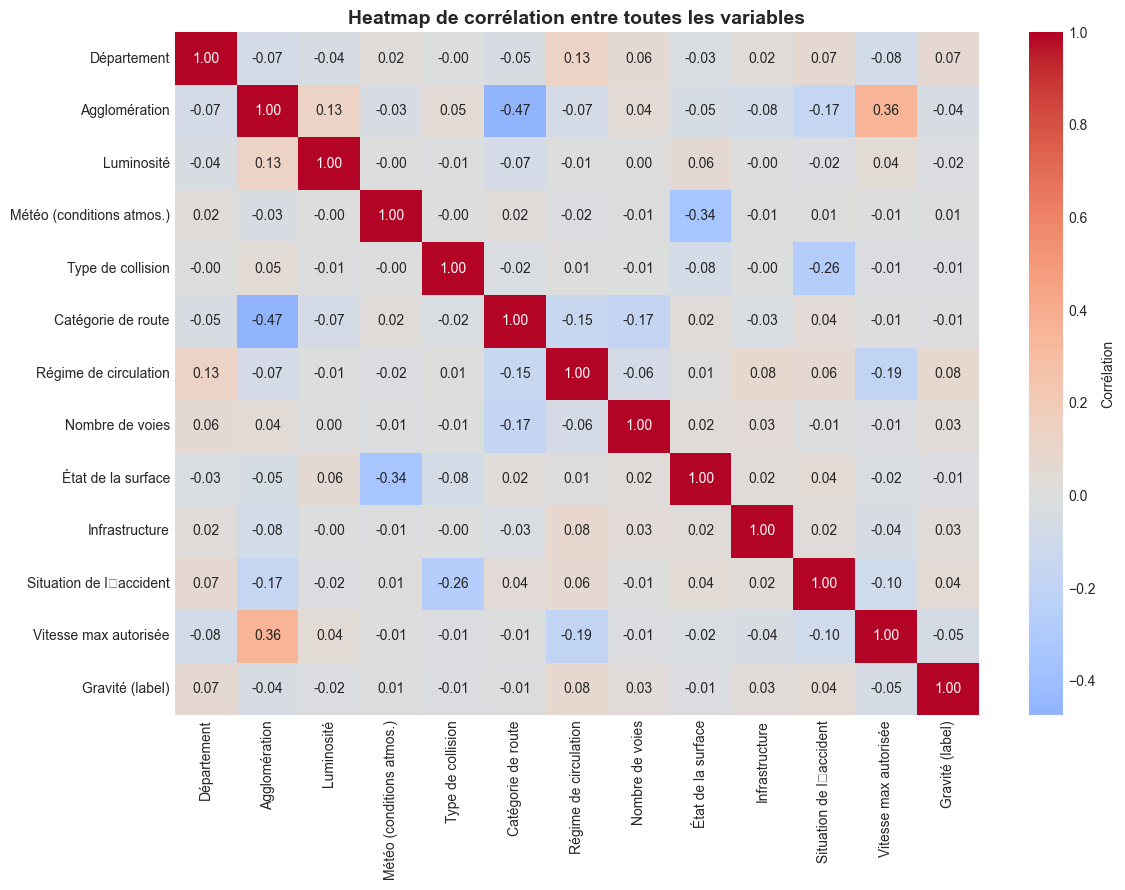

Graphique 5 sauvegardé

EDA terminée — 5 graphiques générés dans /data/


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# notebook autonome : re-chargement et nettoyage minimal pour ne pas dépendre de 01_preparation
df = pd.read_csv('../data/accidents_2024.csv', sep=';', encoding='latin-1')
df.drop_duplicates(inplace=True)
df.dropna(subset=['Gravité (label)'], inplace=True)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

# ordre fixé manuellement : garantit des graphes comparables entre eux
ordre_gravite = ['Blessé léger', 'Blessé hospitalisé', 'Tué']
palette = {'Blessé léger': '#2196F3', 'Blessé hospitalisé': '#FF9800', 'Tué': '#F44336'}

fig, ax = plt.subplots(figsize=(8, 5))
counts = df['Gravité (label)'].value_counts().reindex(ordre_gravite)
bars = ax.bar(counts.index, counts.values, color=[palette[g] for g in counts.index], edgecolor='black')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Répartition des accidents par gravité (2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gravité')
ax.set_ylabel("Nombre d'accidents")
plt.tight_layout()
plt.savefig('../data/01_distribution_gravite.png', dpi=150)
plt.show()
print("Graphique 1 sauvegardé")

# head(5) : les conditions rares ont trop peu d'observations pour être interprétables
meteo_top = df['Météo (conditions atmos.)'].value_counts().head(5).index
df_meteo = df[df['Météo (conditions atmos.)'].isin(meteo_top)]
meteo_gravite = df_meteo.groupby(['Météo (conditions atmos.)', 'Gravité (label)']).size().unstack(fill_value=0)
meteo_gravite_pct = meteo_gravite.div(meteo_gravite.sum(axis=1), axis=0) * 100
meteo_gravite_pct = meteo_gravite_pct.reindex(columns=ordre_gravite)

fig, ax = plt.subplots(figsize=(10, 6))
meteo_gravite_pct.plot(kind='bar', ax=ax, color=[palette[g] for g in ordre_gravite], edgecolor='black')
ax.set_title('Impact de la météo sur la gravité des accidents (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Conditions météorologiques')
ax.set_ylabel('Proportion (%)')
ax.legend(title='Gravité')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/02_meteo_gravite.png', dpi=150)
plt.show()
print("Graphique 2 sauvegardé")

lum_gravite = df.groupby(['Luminosité', 'Gravité (label)']).size().unstack(fill_value=0)
lum_gravite_pct = lum_gravite.div(lum_gravite.sum(axis=1), axis=0) * 100
lum_gravite_pct = lum_gravite_pct.reindex(columns=ordre_gravite)

fig, ax = plt.subplots(figsize=(10, 6))
lum_gravite_pct.plot(kind='bar', ax=ax, color=[palette[g] for g in ordre_gravite], edgecolor='black')
ax.set_title('Impact de la luminosité sur la gravité des accidents (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Conditions de luminosité')
ax.set_ylabel('Proportion (%)')
ax.legend(title='Gravité')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/03_luminosite_gravite.png', dpi=150)
plt.show()
print("Graphique 3 sauvegardé")

route_gravite = df.groupby(['Catégorie de route', 'Gravité (label)']).size().unstack(fill_value=0)
route_gravite_pct = route_gravite.div(route_gravite.sum(axis=1), axis=0) * 100
route_gravite_pct = route_gravite_pct.reindex(columns=ordre_gravite)

fig, ax = plt.subplots(figsize=(10, 6))
route_gravite_pct.plot(kind='bar', ax=ax, color=[palette[g] for g in ordre_gravite], edgecolor='black')
ax.set_title('Impact du type de route sur la gravité des accidents (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie de route')
ax.set_ylabel('Proportion (%)')
ax.legend(title='Gravité')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/04_route_gravite.png', dpi=150)
plt.show()
print("Graphique 4 sauvegardé")

# LabelEncoder uniquement ici pour calculer corr() — pas utilisé en modélisation
from sklearn.preprocessing import LabelEncoder
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
df_enc = df_enc.drop(columns=['Num_Acc'], errors='ignore')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df_enc.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, cbar_kws={'label': 'Corrélation'})
ax.set_title('Heatmap de corrélation entre toutes les variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/05_heatmap_correlation.png', dpi=150)
plt.show()
print("Graphique 5 sauvegardé")

print("\nEDA terminée — 5 graphiques générés dans /data/")